# Regressão

## Introdução

Este projeto foca na modelagem de regressão para investigar a relação entre os hábitos de estudo e o desempenho acadêmico final dos estudantes. O objetivo é construir um preditor capaz de estimar as notas dos alunos com base em variáveis comportamentais.

## Conjunto de Dados

O conjunto de dados foi obtido através do Kaggle (https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance/data) e cobre métricas como tempo de estudo, participação em aulas e engajamento em atividades extracurriculares.


# Imports e Upload do Dataset

Inserção da raiz do projeto no *sys.path* para permitir o *import* do *wrapper* de regressão:

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()

while not (ROOT / "wrappers").exists():
    # print(sys.path[0])
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT))

*Imports* necessários:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from wrappers.regressor import NeuralNetworkRegressor

*Upload* do conjunto de dados:

In [4]:
df = pd.read_csv("../datasets/student_habits_performance.csv")

# Análise Exploratória dos Dados

Nesta etapa, foi realizada uma análise exploratória para compreender a estrutura e as principais características do conjunto de dados. Para isso, serão utilizadas algumas funções do *DataFrame*, que permitem obter informações relevantes sobre o *dataset*:

* **`head()`**: exibe os cinco primeiros registros do conjunto de dados;
* **`info()`**: apresenta informações gerais, como os nomes dos atributos, a quantidade de valores não nulos e o tipo de dado de cada coluna;
* **`describe()`**: fornece estatísticas descritivas das variáveis numéricas, incluindo contagem, média, desvio padrão, valores mínimo, máximo e quartis;
* **`isnull().sum()`**: calcula a quantidade de valores ausentes (*missing values*) em cada atributo.

In [5]:
print("\nHead:")
display(df.head())
print("\nInfo:")
display(df.info())
print("\nDescribe:")
display(df.describe())
print("\nValores nulos:")
print(df.isnull().sum())


Head:


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4



Info:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   str    
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   str    
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   str    
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   str    
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    str    
 12  internet_quality               1000 non-null   str   

None


Describe:


,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000



Valores nulos:
student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
exam_score                        0
dtype: int64


## Significado de Cada Coluna

| Coluna                    | Descrição                                   |
| ------------------------- | ------------------------------------------- |
|**student_id**             | ID do estudante                             |
| **age**                   | Idade do estudante (anos).                  |
| **gender**                | Gênero do estudante.                        |
| **study_hours_per_day**   | Horas de estudo por dia.                    |
| **social_media_hours**    | Horas diárias em redes sociais.             |
| **netflix_hours**         | Horas diárias assistindo Netflix/streaming. |
| **part_time_job**         | Se trabalha meio período ou não.            |
| **attendance_percentage** | Percentual de presença nas aulas.           |
| **sleep_hours**           | Horas de sono por dia.                      |
| **diet_quality**          | Qualidade da dieta.                         |
| **exercise_frequency**    | Frequência semanal de exercícios físicos.           |
| **parental_education_level**    | Nível de educação dos pais.           |
| **internet_quality**    | Qualidade da internet.           |
| **mental_health_rating**  | Autoavaliação da saúde mental.              |
| **extracurricular_participation**  | Se participa de extracurricular ou não.              |
| **exam_score**            | Nota obtida na prova.                       |


Para complementar a análise exploratória, foram gerados gráficos de alguns atributos do *dataset*, possibilitando uma melhor compreensão da distribuição e do comportamento dos dados:

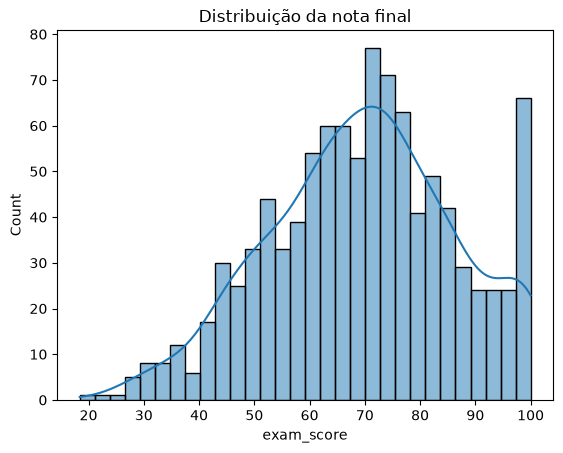

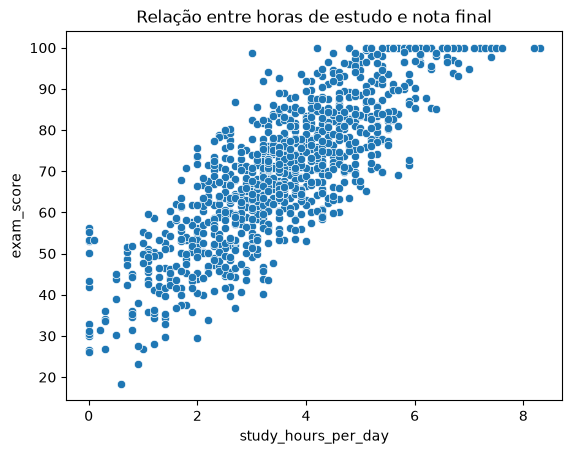

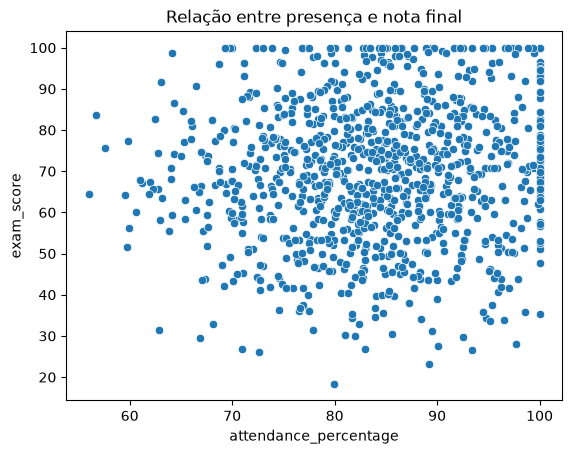

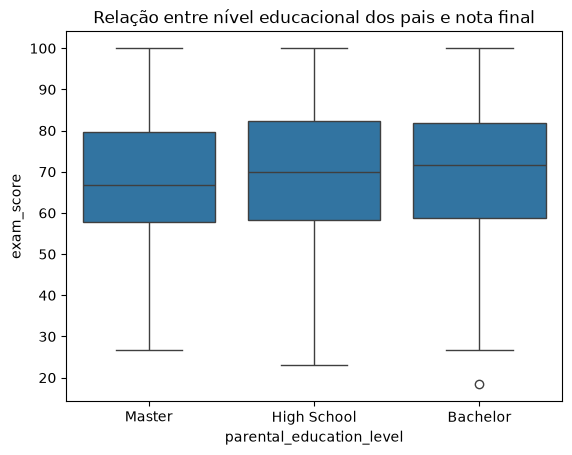

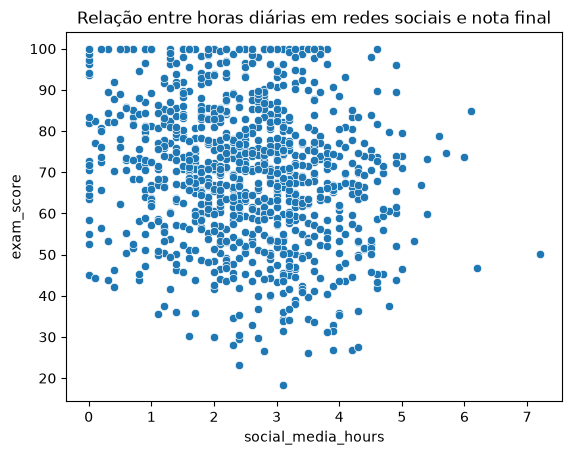

In [8]:
# Dist. nota final.
sns.histplot(df["exam_score"], bins=30, kde=True)
plt.title("Distribuição da nota final")
plt.show()

# Horas de estudo.
sns.scatterplot(
    data=df,
    x="study_hours_per_day",
    y="exam_score"
)
plt.title("Relação entre horas de estudo e nota final")
plt.show()

# Presença.
sns.scatterplot(
    data=df,
    x="attendance_percentage",
    y="exam_score"
)
plt.title("Relação entre presença e nota final")
plt.show()

# Nível educacional dos pais.
sns.boxplot(
    data=df,
    x="parental_education_level",
    y="exam_score"
)
plt.title("Relação entre nível educacional dos pais e nota final")
plt.show()

# Redes sociais.
sns.scatterplot(
    data=df,
    x="social_media_hours",
    y="exam_score"
)
plt.title("Relação entre horas diárias em redes sociais e nota final")
plt.show()

# Tratamento dos Dados

Nesta etapa, foi realizado o pré-processamento do conjunto de dados. Inicialmente, foram definidas as variáveis preditoras (*features*) e a variável alvo (*exam_score*), removendo do conjunto de atributos o identificador do estudante (*student_id*) e a variável objetivo. Em seguida, a variável alvo foi normalizada utilizando o método *StandardScaler*, enquanto os atributos foram separados em variáveis numéricas e categóricas. Por fim, foi definido um *pipeline* de pré-processamento para tratar valores ausentes, normalizar os atributos numéricos e aplicar a codificação *One-Hot Encoding* às variáveis categóricas, preparando os dados para o treinamento dos modelos de regressão.

In [6]:
# X = Drop de todas as colunas pouco significativas para o problema.
X = df.drop(columns=["student_id", "exam_score"])
display(X.head())

# y = Objetivo.
y = df["exam_score"]
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y.values.reshape(-1, 1)).ravel()


numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Preencher valores faltantes com a mediana e normalizar.
numerical_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

# Preencher valores faltantes com o mais frequente e fazer one-hot-encoding.
categorical_transformer = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

# Combinar os dois transformadores.
preprocessor = ColumnTransformer(
    [
        ("num", numerical_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No


/tmp/ipykernel_2711641/1574922362.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns.tolist()


# Treinamento

Nesta etapa, o conjunto de dados foi dividido em dois subconjuntos: treinamento (80%) e teste (20%), permitindo avaliar a capacidade de generalização dos modelos em dados não utilizados durante o treinamento. A variável alvo foi previamente normalizada para facilitar o processo de aprendizado dos modelos baseados em redes neurais e, posteriormente, seus valores foram convertidos novamente para a escala original para a avaliação dos resultados.

Em seguida, foram definidos os modelos de regressão que seriam avaliados: uma Rede Neural Multicamadas (MLP), uma *Random Forest*, um *Gradient Boosting* e a Rede Neural implementada neste trabalho. Para cada modelo, foram especificados os hiperparâmetros selecionados na etapa de [Escolha dos Hiperparâmetros](#extra-escolha-dos-hiperparâmetros).

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_scaled,
    test_size=0.2,
    random_state=42
)
y_test_original = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()

models = {
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64,),
        activation='tanh',
        alpha=0.001,
        solver='adam',
        learning_rate_init=0.01,
        max_iter=5000,
        random_state=42
    ),
    "RF": RandomForestRegressor(
        n_estimators=300,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='log2',
        max_depth=20,
        random_state=42
    ),
    "GB": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=2,
        random_state=42
    ),
    "NN (Our)": NeuralNetworkRegressor(
        hidden_layers=(128, 64, 32),
        hidden_activation="sigmoid",
        learning_rate=0.01,
        epochs=200,
        batch_size=32,
    )
}

Nesta etapa, cada modelo foi integrado ao *pipeline* de pré-processamento e treinado utilizando o conjunto de treinamento. Após o treinamento, os modelos realizaram previsões sobre o conjunto de teste. Como a variável alvo foi normalizada durante o pré-processamento, as predições foram convertidas novamente para a escala original antes da avaliação. O desempenho de cada modelo foi mensurado por meio das métricas Erro Absoluto Médio (MAE), Raiz do Erro Quadrático Médio (RMSE) e Coeficiente de Determinação (R²), além do registro dos tempos de treinamento e de inferência.

In [21]:
results = []

for name, model in models.items():
    pipeline = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    start = time.time()
    y_pred_scaled = pipeline.predict(X_test)
    y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    elapsed = time.time() - start

    mae = mean_absolute_error(y_test_original, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_original, y_pred))
    r2 = r2_score(y_test_original, y_pred)
    results.append([
        name,
        mae,
        rmse,
        r2,
        train_time,
        elapsed
    ])

Após a avaliação dos modelos, os resultados obtidos foram organizados em uma tabela comparativa, reunindo as principais métricas de desempenho e os tempos de treinamento e inferência de cada algoritmo. Em seguida, foi gerado um gráfico de barras para facilitar a comparação visual entre os modelos, destacando métricas como MAE, RMSE, R² e tempo de treinamento.

,Modelo,MAE,RMSE,R2,Tempo de Treinamento,Tempo de Inferência
0,MLP,6.319095,7.799476,0.762773,0.257863,0.004910
1,RF,6.226351,8.114519,0.743222,0.454353,0.029654
2,GB,4.563373,5.483137,0.882756,0.574778,0.006866
3,NN (Our),4.176257,5.144098,0.896807,2.165411,0.006271


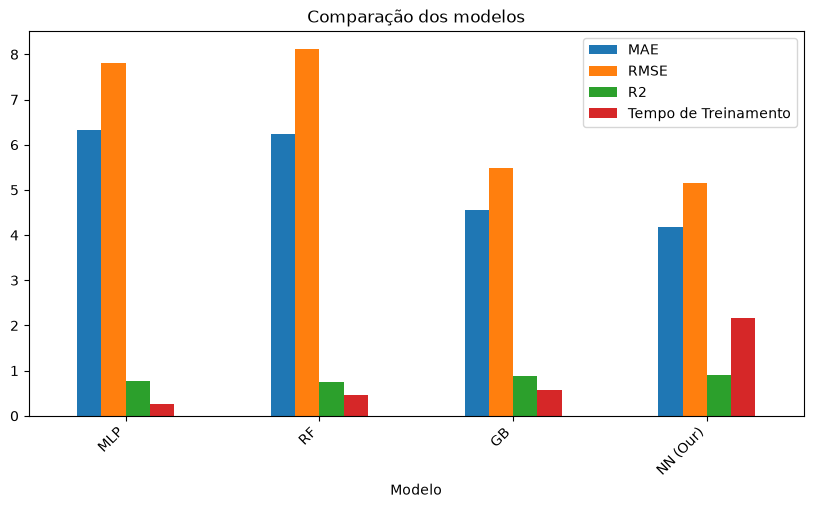

In [22]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Modelo",
        "MAE",
        "RMSE",
        "R2",
        "Tempo de Treinamento",
        "Tempo de Inferência"
    ]
)
display(results_df)

results_df.plot(
    x='Modelo',
    y=['MAE','RMSE','R2', 'Tempo de Treinamento'],
    kind='bar',
    figsize=(10,5)
)
plt.xticks(rotation=45, ha='right')
plt.title("Comparação dos modelos")
plt.show()

# Conclusão

Os resultados obtidos mostram que a rede neural desenvolvida neste trabalho (NN) apresentou o melhor desempenho entre os modelos avaliados, alcançando os menores valores de MAE (4.18) e RMSE (5.14), além do maior R² (0.8968), indicando maior precisão nas previsões. O *Gradient Boosting* (GB) obteve resultados bastante próximos, com desempenho competitivo e menor tempo de treinamento, configurando-se como uma alternativa eficiente.

Já os modelos MLP e *Random Forest* (RF) apresentaram erros mais elevados e menores valores de R², demonstrando menor capacidade preditiva para este conjunto de dados. Embora a rede neural proposta tenha exigido maior tempo de treinamento, o ganho obtido nas métricas de erro e no coeficiente de determinação justifica sua utilização em cenários onde a qualidade das previsões é o principal critério de avaliação. Por outro lado, o *Gradient Boosting* mostrou-se uma excelente alternativa quando se deseja um desempenho muito próximo ao da rede neural, porém com menor tempo de treinamento.

# Extra: Escolha dos Hiperparâmetros

Nesta etapa, foi realizada a otimização dos hiperparâmetros dos modelos de regressão com o objetivo de identificar as configurações que proporcionam melhor desempenho. Para cada algoritmo, foi definido um *pipeline* contendo o pré-processamento dos dados e o modelo correspondente, além de um conjunto de hiperparâmetros candidatos. A busca foi realizada utilizando o método *Randomized Search* com validação cruzada de cinco *folds* (*5-fold Cross Validation*), avaliando diferentes combinações de hiperparâmetros de forma aleatória. Como critério de seleção, foi utilizada a métrica *R² score* (Coeficiente de Determinação). Ao final do processo, foram registrados o melhor valor de R² obtido durante a validação cruzada (o valor mais próximo de 1) e a combinação de hiperparâmetros correspondente para cada modelo.

In [9]:
mlp_pipeline = Pipeline(
    [("prep", preprocessor), ("model", MLPRegressor(max_iter=5000, random_state=42, early_stopping=True))]
)

mlp_params = {
    "model__hidden_layer_sizes": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
    ],
    "model__solver": ["adam"],
    "model__activation": ["relu", "tanh"],
    "model__alpha": [0, 0.0001, 0.001, 0.01],
    "model__learning_rate_init": [0.0001, 0.001, 0.01],
}

rf_pipeline = Pipeline(
    [("prep", preprocessor), ("model", RandomForestRegressor(random_state=42))]
)

rf_params = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [None, 5, 10, 15, 20],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

gb_pipeline = Pipeline(
    [("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]
)

gb_params = {
    "model__n_estimators": [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [2, 3, 5, 7],
}

nn_pipeline = Pipeline([("prep", preprocessor), ("model", NeuralNetworkRegressor())])
nn_params = {
    "model__hidden_layers": [
        (32,),
        (64,),
        (128,),
        (64, 32),
        (128, 64),
        (128, 64, 32),
    ],
    "model__hidden_activation": [
        "relu",
        "sigmoid",
        "tanh",
        "leaky_relu",
        "elu",
        "selu",
    ],
    "model__learning_rate": [
        0.0001,
        0.001,
        0.01,
    ],
    "model__epochs": [200, 500, 1000, 3000],
    "model__batch_size": [None, 8, 16, 32, 64],
}

In [10]:
from sklearn.model_selection import RandomizedSearchCV


def run_search(pipeline, params, n_iter=50):
    search = RandomizedSearchCV(
        pipeline,
        params,
        n_iter=n_iter,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        random_state=42,
        verbose=0,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    return search

print("MLP - Buscando hiperparâmetros...")
mlp_search = run_search(mlp_pipeline, mlp_params)
print(f"  Melhor R2: {mlp_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {mlp_search.best_params_}")

print("RF - Buscando hiperparâmetros...")
rf_search = run_search(rf_pipeline, rf_params)
print(f"  Melhor R2: {rf_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {rf_search.best_params_}")

print("GB - Buscando hiperparâmetros...")
gb_search = run_search(gb_pipeline, gb_params)
print(f"  Melhor R2: {gb_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {gb_search.best_params_}")

print("NN - Buscando hiperparâmetros...")
nn_search = run_search(nn_pipeline, nn_params)
print(f"  Melhor R2: {nn_search.best_score_:.4f}")
print(f"  Melhores parâmetros:  {nn_search.best_params_}")

MLP - Buscando hiperparâmetros...
  Melhor R2: 0.8959
  Melhores parâmetros:  {'model__solver': 'adam', 'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (64,), 'model__alpha': 0.001, 'model__activation': 'tanh'}
RF - Buscando hiperparâmetros...
  Melhor R2: 0.7209
  Melhores parâmetros:  {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 20}
GB - Buscando hiperparâmetros...


/home/anaard/Desktop/ufsc/ine5664/ine5664-projeto-final/notebooks/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:326: UserWarning: The total space of parameters 36 is smaller than n_iter=50. Running 36 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


  Melhor R2: 0.8843
  Melhores parâmetros:  {'model__n_estimators': 500, 'model__max_depth': 2, 'model__learning_rate': 0.05}
NN - Buscando hiperparâmetros...
  Melhor R2: 0.9043
  Melhores parâmetros:  {'model__learning_rate': 0.01, 'model__hidden_layers': (128, 64, 32), 'model__hidden_activation': 'sigmoid', 'model__epochs': 200, 'model__batch_size': 32}
